In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Shopping_Mall_Customer_Data.csv')
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer ID     15079 non-null  str  
 1   Age             15079 non-null  int64
 2   Gender          15079 non-null  str  
 3   Annual Income   15079 non-null  int64
 4   Spending Score  15079 non-null  int64
dtypes: int64(3), str(2)
memory usage: 1.2 MB


In [4]:
df.shape

(15079, 5)

## Check for NUll Values, Data Type Errors and Duplicates.

In [5]:
df.isnull().sum()

Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(15079, 5)

- NO NUll Values
- No Duplicates
- Data types are correct

In [8]:
df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


### As we can see here, in all the numerical columns, the mean and the median are almost similar. So we can say that the data does not have any outliers. 

## Data Analysis

In [9]:
#Average Age of Customers
print(f"Avg Age of Customers = {df['Age'].mean():.2f}")

Avg Age of Customers = 54.19


In [10]:
#Average Annual Income of Customers
print(f"Avg Annual Income of Customers = {df['Annual Income'].mean():.2f}")

Avg Annual Income of Customers = 109742.88


In [11]:
# Which gender spends more?
gender_spending = df.groupby('Gender')['Spending Score'].mean()
print(gender_spending)

Gender
Female    50.397648
Male      50.782752
Name: Spending Score, dtype: float64


#### Spending behavior is nearly uniform across genders, indicating marketing campaigns need not be gender-specific

In [12]:
df['Age'].min()

np.int64(18)

In [13]:
# coverting age into age groups using pd.cut(). this function is used to cut a continuous data into groups.
df['age_group'] = pd.cut(
                            df['Age'], bins= [18, 38, 58, 78, 98 ], labels= ['18-38', '39-58', '59-78', '79-98']
)

df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score,age_group
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89,18-38
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95,39-58
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76,59-78
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57,18-38
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76,18-38


In [14]:
agegrp_spending = df.groupby('age_group')['Spending Score'].mean().sort_values(ascending=False)
print(agegrp_spending)

age_group
39-58    50.867021
18-38    50.712099
59-78    50.422081
79-98    50.258763
Name: Spending Score, dtype: float64


C:\Users\singh\AppData\Local\Temp\ipykernel_4224\1234273992.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='age_group', y='Spending Score', data=df, ci = None)


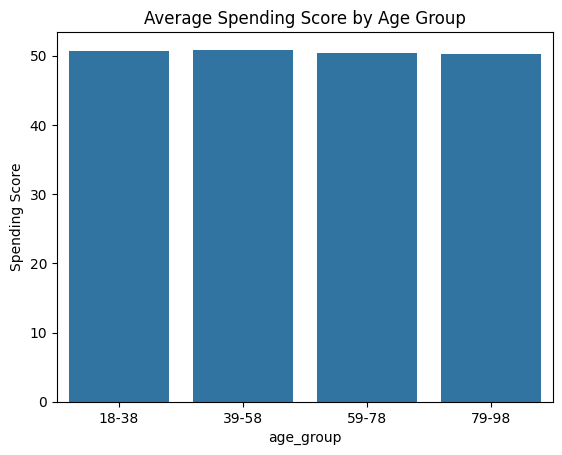

In [15]:
sns.barplot(x='age_group', y='Spending Score', data=df, ci = None)
plt.title('Average Spending Score by Age Group')
plt.show()

Age group 39-58 has the highest spending score. 
Age group 79-98 has the least spending score.

C:\Users\singh\AppData\Local\Temp\ipykernel_4224\3371429653.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Income_grp', y='Spending Score', data=df, ci= None)


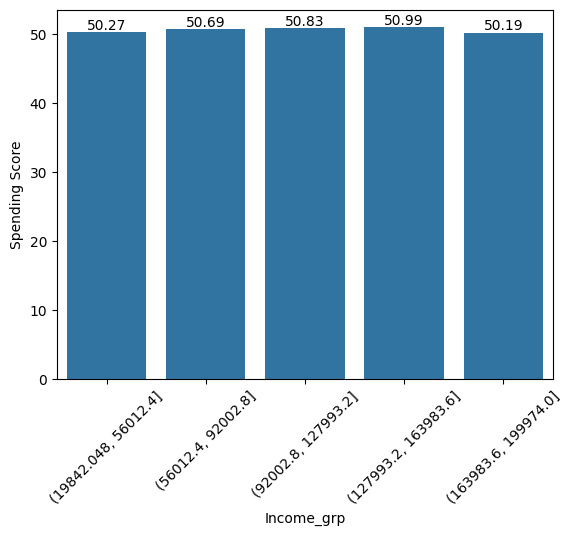

In [16]:
df['Income_grp'] = pd.cut(df['Annual Income'], bins= 5)
ax = sns.barplot(x='Income_grp', y='Spending Score', data=df, ci= None)
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge')
plt.show()

Income_grp
(19842.048, 56012.4]    3084
(163983.6, 199974.0]    3064
(92002.8, 127993.2]     2983
(127993.2, 163983.6]    2976
(56012.4, 92002.8]      2972
Name: count, dtype: int64

There is no significant difference in spending score across different income groups. 

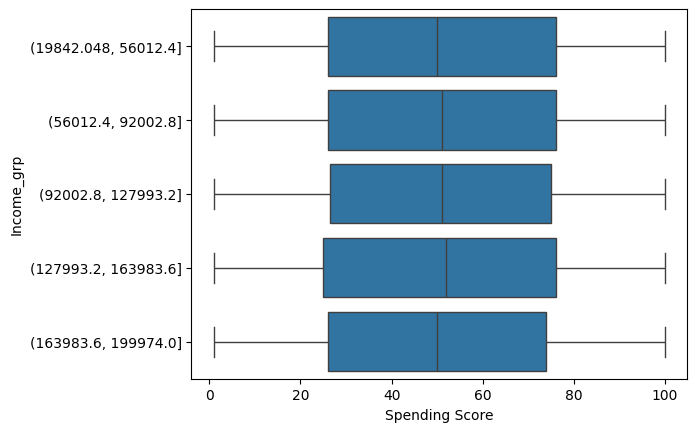

In [17]:
sns.boxplot(x= 'Spending Score', y= 'Income_grp', data=df)
plt.show()

From this visual, we can conclude that in each income group there are:
- low spenders
- medium spenders
- high spenders

So actually, the customer spending behavior varies widely in the same income group, And this is similar across all income groups. 
Hence, we can say that spending is not actually related to income. 

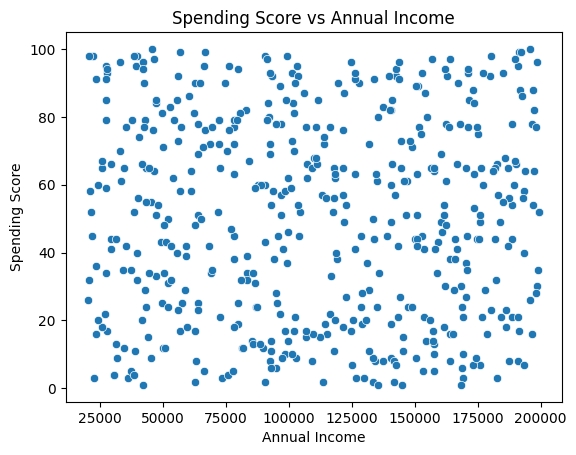

In [18]:
df_sample = df.sample(500)
sns.scatterplot(x='Annual Income', y='Spending Score', data=df_sample)
plt.title('Spending Score vs Annual Income')
plt.show()

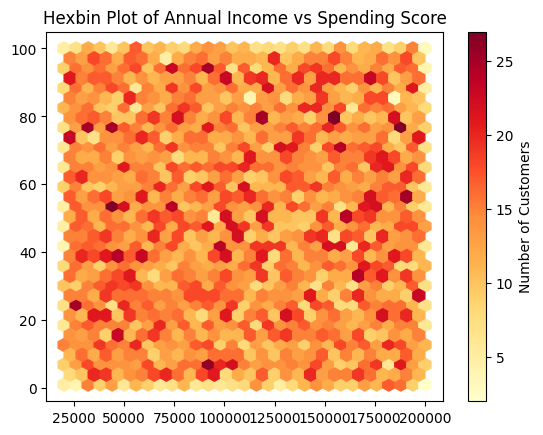

In [19]:
plt.hexbin(x = 'Annual Income', y = 'Spending Score', data = df, gridsize = 30, cmap='YlOrRd')
plt.colorbar(label='Number of Customers')
plt.title('Hexbin Plot of Annual Income vs Spending Score')
plt.show()

There is no strong concentration of customers in any particular region. Customers are fairly evenly distributed across income and spending levels.

### Customer Segmentation

In [20]:
income_avg = df['Annual Income'].mean()
spending_avg = df['Spending Score'].mean()

def segment(i):
    if i['Annual Income'] >= income_avg and i['Spending Score'] >= spending_avg:
        return 'High Income - High Spending'
    elif i['Annual Income'] >= income_avg and i['Spending Score'] < spending_avg:
        return 'High Income - Low Spending'
    elif i['Annual Income'] < income_avg and i['Spending Score'] >= spending_avg:
        return 'Low Income - High Spending'
    else:
        return 'Low Income - Low Spending'
    
df['Segment'] = df.apply(segment, axis=1)
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score,age_group,Income_grp,Segment
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89,18-38,"(127993.2, 163983.6]",High Income - High Spending
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95,39-58,"(163983.6, 199974.0]",High Income - High Spending
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76,59-78,"(56012.4, 92002.8]",Low Income - High Spending
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57,18-38,"(19842.048, 56012.4]",Low Income - High Spending
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76,18-38,"(127993.2, 163983.6]",High Income - High Spending


In [21]:
df.to_csv('Cleaned_data.csv', index=False)